# Walk-Forward XGBoost Models — Weekly Fantasy Points (PPR)

Improves on `baseline_model.ipynb` in three ways:

1. **True walk-forward validation** — instead of one static weeks 1–10 / 11+ split, the model is retrained for *every* test week using only data available before that week. This is exactly how the model would be used in production.
2. **Early stopping** — each weekly fold trains up to 500 boosting rounds but stops when error on a held-out validation week (the most recent completed week) stops improving. This picks the right model complexity per fold automatically.
3. **Per-position models** — separate QB / RB / WR / TE regressors, each given only the features relevant to that position, compared head-to-head against the single global model.

4. **Hyperparameter tuning without test leakage** — a small grid is evaluated with the same walk-forward procedure on *tuning weeks 5–10* of the test season. The winning config is then run once on the untouched *test weeks 11–17*. The test weeks never influence hyperparameter selection.

**Fantasy season scope:** only weeks 1–17 are modeled. Week 18 (starters rest) and playoff weeks 19–22 are excluded entirely — they are outside the fantasy season and their usage patterns would pollute training.

**Fold layout for predicting week W of the latest season:** train on all prior seasons *plus* the current season's weeks 1 … W−2, validate (early stopping) on week W−1, predict week W.

In [1]:
# Install modeling dependencies (pandas/numpy come with the feature notebook)
%pip install xgboost scikit-learn matplotlib


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: /private/tmp/ffe_venv/bin/python -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


## Load Gold DataFrame and Preprocess

Same preprocessing as the baseline: drop identifiers, drop same-week outcome columns (leakage guard), keep only pre-game features. `position` is kept aside for row selection and per-position evaluation instead of being one-hot encoded — the global model gets the dummies, the per-position models don't need them.

In [2]:
import pandas as pd
import numpy as np

# In Databricks, produce gold_df by running the feature engineering notebook:
# %run ../ingestion/feature_building

# Standalone fallback: load the Gold table saved by the feature notebook
if 'gold_df' not in globals():
    gold_df = pd.read_parquet('../data/gold_df.parquet')

# Fantasy season is weeks 1-17. Week 18 (rest week) and playoffs (19-22) are
# excluded from BOTH training and evaluation.
FANTASY_MAX_WEEK = 17
gold_df = gold_df[gold_df['week'] <= FANTASY_MAX_WEEK]

TARGET = 'fantasy_points_ppr'

# Identity columns kept aside for evaluation (index stays aligned)
eval_meta = gold_df[['player_id', 'player_name', 'recent_team', 'position', 'season', 'week']].copy()

df = gold_df.copy()

# Non-predictive identifiers
identifier_cols = [
    'player_id', 'player_name', 'recent_team',
    'opponent', 'starting_qb_id', 'gameday',
]
df = df.drop(columns=[c for c in identifier_cols if c in df.columns])

# Same-week outcome columns: raw stats of the game being predicted.
# They exist in gold_df only as intermediates for the shifted features —
# keeping them would leak the answer (receptions directly determine PPR).
same_week_outcome_cols = [
    'pass_attempts', 'completions', 'passing_yards', 'passing_tds', 'interceptions',
    'rush_attempts', 'rushing_yards', 'rushing_tds',
    'targets', 'receptions', 'receiving_yards', 'receiving_tds',
    'player_opportunities', 'team_total_opportunities', 'opportunity_share',
    'hvt_carries', 'hvt_targets', 'total_hvts',
    'team_pass_attempts', 'target_share',
    'player_air_yards', 'team_air_yards', 'air_yards_share',
    'wopr', 'snap_share',
]
df = df.drop(columns=[c for c in same_week_outcome_cols if c in df.columns])

# Keep position as a plain column here; the global model adds dummies below
df['position'] = eval_meta['position']
df = df.fillna(0)

print(f"Modeling dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Seasons: {sorted(df['season'].unique())}, weeks {df['week'].min()} - {df['week'].max()}")

Modeling dataset: 26,359 rows x 41 columns
Seasons: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)], weeks 1 - 17


## Walk-Forward Engine

One reusable function: for each test week W it trains on weeks ≤ W−2, early-stops against week W−1, and predicts week W. Returns out-of-sample predictions for every test row, exactly as a production system retraining weekly would generate them.

In [3]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

FIRST_TEST_WEEK = 11

DEFAULT_PARAMS = dict(learning_rate=0.05, max_depth=4)


def make_model(params=None):
    """Up to 500 boosting rounds with early stopping (20 rounds patience on
    the validation week), plus whatever hyperparameters the tuning stage picks."""
    return XGBRegressor(
        n_estimators=500,
        early_stopping_rounds=20,
        random_state=42,
        n_jobs=-1,
        **(params or DEFAULT_PARAMS),
    )


def walk_forward(data, feature_cols, label, params=None,
                 first_test_week=FIRST_TEST_WEEK, last_test_week=None, verbose=True):
    """Run weekly walk-forward validation over first_test_week..last_test_week
    of the most recent season. Earlier seasons are always fully in the training
    set (they are in the past relative to every test week).

    data must contain 'season', 'week', TARGET, and feature_cols.
    Returns a DataFrame (indexed like `data`) with actual/predicted per test row.
    """
    folds = []
    test_season = data['season'].max()
    in_test_season = data['season'] == test_season
    test_weeks = sorted(
        w for w in data.loc[in_test_season, 'week'].unique()
        if w >= first_test_week and (last_test_week is None or w <= last_test_week)
    )

    for w in test_weeks:
        train = data[~in_test_season | (data['week'] <= w - 2)]
        val = data[in_test_season & (data['week'] == w - 1)]
        test = data[in_test_season & (data['week'] == w)]
        if test.empty or val.empty or len(train) < 50:
            continue

        model = make_model(params)
        model.fit(
            train[feature_cols], train[TARGET],
            eval_set=[(val[feature_cols], val[TARGET])],
            verbose=False,
        )
        preds = model.predict(test[feature_cols])

        fold = pd.DataFrame(
            {'actual': test[TARGET].values, 'predicted': preds}, index=test.index
        )
        fold['test_week'] = w
        fold['best_iteration'] = model.best_iteration
        folds.append(fold)

    results = pd.concat(folds)
    mae = mean_absolute_error(results['actual'], results['predicted'])
    if verbose:
        print(f"[{label}] {len(results):,} test rows across weeks "
              f"{results['test_week'].min()}-{results['test_week'].max()} | MAE = {mae:.2f}")
    return results


def mae_by_position(results, label):
    """Position-level MAE for a walk-forward results frame."""
    r = results.join(eval_meta['position'])
    out = (
        r.assign(abs_error=(r['actual'] - r['predicted']).abs())
        .groupby('position')['abs_error'].mean()
        .reindex(['QB', 'RB', 'WR', 'TE'])
        .rename(label)
        .round(2)
    )
    return out

## Hyperparameter Tuning (leakage-safe)

The grid is scored with the *same walk-forward procedure* but on **tuning weeks 5–10** of the test season — strictly before the final test window. Weeks 11–17 never influence which config wins, so the reported test MAE stays honest.

The grid stays deliberately small and regularization-heavy (shallow trees, row/column subsampling, `min_child_weight`) because weekly fantasy data is noisy — with ~25k training rows an aggressive grid would just overfit the tuning weeks.

In [4]:
# ============================================================================
# HYPERPARAMETER TUNING — walk-forward on weeks 5-10 (test weeks untouched)
# ============================================================================
from itertools import product

TUNE_FIRST_WEEK, TUNE_LAST_WEEK = 5, 10

tune_df = pd.get_dummies(df, columns=['position'], prefix='pos')
tune_features = [c for c in tune_df.columns if c != TARGET]

param_grid = [
    dict(max_depth=d, learning_rate=lr, min_child_weight=mcw,
         subsample=0.8, colsample_bytree=0.8)
    for d, lr, mcw in product([3, 4, 6], [0.03, 0.05], [1, 5])
]

tuning_rows = []
for params in param_grid:
    res = walk_forward(
        tune_df, tune_features, label='tune', params=params,
        first_test_week=TUNE_FIRST_WEEK, last_test_week=TUNE_LAST_WEEK, verbose=False,
    )
    mae = mean_absolute_error(res['actual'], res['predicted'])
    tuning_rows.append({**params, 'tune_mae': round(mae, 3)})
    print(f"  depth={params['max_depth']} lr={params['learning_rate']} "
          f"mcw={params['min_child_weight']} -> tuning MAE {mae:.3f}")

tuning_table = pd.DataFrame(tuning_rows).sort_values('tune_mae').reset_index(drop=True)
BEST_PARAMS = {k: tuning_table.iloc[0][k] for k in
               ['max_depth', 'learning_rate', 'min_child_weight', 'subsample', 'colsample_bytree']}
BEST_PARAMS['max_depth'] = int(BEST_PARAMS['max_depth'])
BEST_PARAMS['min_child_weight'] = int(BEST_PARAMS['min_child_weight'])

print("\nTop 5 configs on tuning weeks 5-10:")
display(tuning_table.head(5))
print(f"\nSelected hyperparameters (used for ALL final models): {BEST_PARAMS}")

  depth=3 lr=0.03 mcw=1 -> tuning MAE 4.942


  depth=3 lr=0.03 mcw=5 -> tuning MAE 4.941


  depth=3 lr=0.05 mcw=1 -> tuning MAE 4.912


  depth=3 lr=0.05 mcw=5 -> tuning MAE 4.934


  depth=4 lr=0.03 mcw=1 -> tuning MAE 4.916


...

  depth=6 lr=0.03 mcw=5 -> tuning MAE 4.927


  depth=6 lr=0.05 mcw=1 -> tuning MAE 4.926


  depth=6 lr=0.05 mcw=5 -> tuning MAE 4.913

Top 5 configs on tuning weeks 5-10:


,max_depth,learning_rate,min_child_weight,subsample,colsample_bytree,tune_mae
0,4,0.05,1,0.8,0.8,4.903
1,4,0.05,5,0.8,0.8,4.910
2,3,0.05,1,0.8,0.8,4.912
3,6,0.05,5,0.8,0.8,4.913
4,4,0.03,1,0.8,0.8,4.916



Selected hyperparameters (used for ALL final models): {'max_depth': 4, 'learning_rate': np.float64(0.05), 'min_child_weight': 1, 'subsample': np.float64(0.8), 'colsample_bytree': np.float64(0.8)}


## Model A: Global Walk-Forward Model

One model for all positions (position one-hot encoded), retrained every week with early stopping.

In [5]:
# ============================================================================
# MODEL A: GLOBAL WALK-FORWARD (all positions, one model)
# ============================================================================
global_df = pd.get_dummies(df, columns=['position'], prefix='pos')
global_features = [c for c in global_df.columns if c != TARGET]

global_results = walk_forward(global_df, global_features,
                              label='Global walk-forward (tuned)', params=BEST_PARAMS)

print("\nAverage early-stopped rounds per fold:",
      int(global_results.groupby('test_week')['best_iteration'].first().mean()))
print("\nMAE by position:")
print(mae_by_position(global_results, 'global_wf').to_string())

[Global walk-forward (tuned)] 1,808 test rows across weeks 11-17 | MAE = 4.89

Average early-stopped rounds per fold: 92

MAE by position:
position
QB    6.39
RB    4.72
WR    4.65
TE    4.92


## Model B: Per-Position Walk-Forward Models

One model per position, each trained only on that position's rows and given only the features relevant to it (shared game-context features plus the position's own feature group). QB and TE samples are small (~30 starters per week), so shallow trees and early stopping matter here.

In [6]:
# ============================================================================
# MODEL B: PER-POSITION WALK-FORWARD MODELS
# ============================================================================

# Features every position shares (game environment + form + generic matchup)
shared_features = [
    'season', 'week', 'implied_total', 'team_spread', 'team_win_prob',
    'is_home', 'temp', 'wind',
    'is_bad_weather', 'is_dome', 'rest_advantage', 'depth_chart_rank',
    'fantasy_points_3wk_avg', 'fantasy_points_5wk_avg',
    'prev_season_ppg', 'prev_season_games',
    'opp_def_ppg_allowed', 'opp_def_ypp_allowed',
]

# Position-specific feature groups (from the CONTEXT business rules)
pass_catcher_features = [
    'wr_te_target_share_3wk_avg', 'wr_te_target_share_5wk_avg',
    'wr_te_air_yards_share_3wk_avg', 'wr_te_air_yards_share_5wk_avg',
    'wr_te_wopr_3wk_avg', 'wr_te_wopr_5wk_avg',
    'starting_qb_aya', 'opp_def_sack_rate',
]
position_features = {
    'QB': [
        'qb_pass_attempts_3wk_avg', 'qb_pass_attempts_5wk_avg',
        'qb_rushing_yards_3wk_avg', 'qb_rushing_yards_5wk_avg',
        'opp_def_sack_rate', 'team_sack_rate_allowed', 'wr1_wr2_healthy',
    ],
    'RB': [
        'rb_opportunity_share_3wk_avg', 'rb_opportunity_share_5wk_avg',
        'rb_hvts_3wk_avg', 'rb_hvts_5wk_avg',
        'rb_snap_share_3wk_avg', 'rb_snap_share_5wk_avg',
        'opp_def_ypc_allowed',
    ],
    'WR': pass_catcher_features + ['wr1_wr2_healthy'],
    'TE': pass_catcher_features,
}

position_results = {}
for pos, extra_features in position_features.items():
    pos_df = df[df['position'] == pos].drop(columns=['position'])
    features = shared_features + extra_features
    position_results[pos] = walk_forward(pos_df, features, label=f'{pos} model', params=BEST_PARAMS)

per_position_results = pd.concat(position_results.values())

overall_pp_mae = mean_absolute_error(
    per_position_results['actual'], per_position_results['predicted']
)
print(f"\nPER-POSITION MODELS OVERALL MAE: {overall_pp_mae:.2f}")
print("\nMAE by position:")
print(mae_by_position(per_position_results, 'per_position_wf').to_string())

[QB model] 198 test rows across weeks 11-17 | MAE = 6.36


[RB model] 556 test rows across weeks 11-17 | MAE = 4.74


[WR model] 855 test rows across weeks 11-17 | MAE = 4.60


[TE model] 199 test rows across weeks 11-17 | MAE = 5.01

PER-POSITION MODELS OVERALL MAE: 4.88

MAE by position:
position
QB    6.36
RB    4.74
WR    4.60
TE    5.01


## Comparison: Naive vs Global vs Per-Position

All three evaluated on the identical set of out-of-sample test rows (weeks 11–17 of the test season). The naive baseline predicts every player's shifted 3-week average — any real model must beat it.

MAE COMPARISON (lower is better):
          naive_3wk_avg  global_wf  per_position_wf
position                                           
QB                 7.19       6.39             6.36
RB                 5.09       4.72             4.74
WR                 5.13       4.65             4.60
TE                 5.45       4.92             5.01
OVERALL            5.38       4.89             4.88


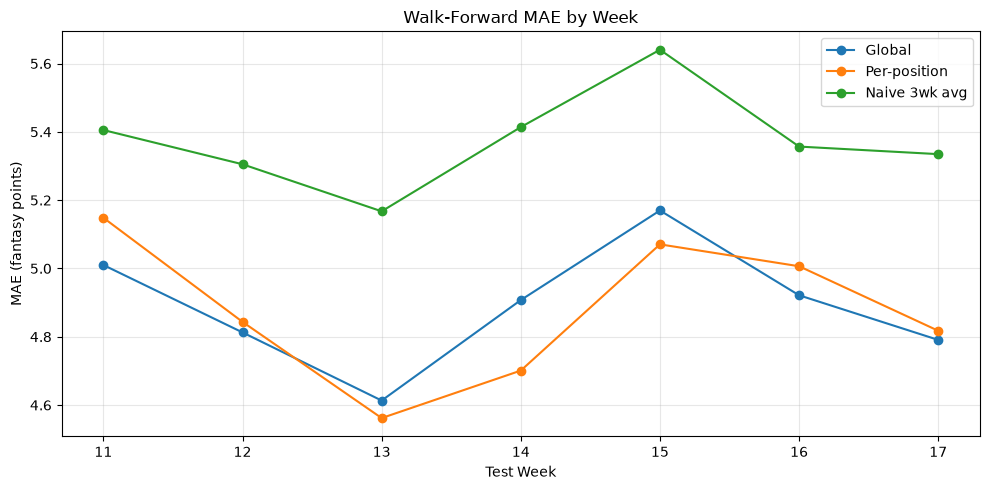

In [7]:
# ============================================================================
# HEAD-TO-HEAD COMPARISON (same test rows for every approach)
# ============================================================================
import matplotlib.pyplot as plt

test_idx = global_results.index

# Naive baseline: predict the player's shifted 3-week fantasy point average
naive_pred = df.loc[test_idx, 'fantasy_points_3wk_avg']
naive_results = pd.DataFrame(
    {'actual': df.loc[test_idx, TARGET], 'predicted': naive_pred}, index=test_idx
)
naive_results['test_week'] = global_results['test_week']

comparison = pd.concat(
    [
        mae_by_position(naive_results, 'naive_3wk_avg'),
        mae_by_position(global_results, 'global_wf'),
        mae_by_position(per_position_results.loc[test_idx], 'per_position_wf'),
    ],
    axis=1,
)
comparison.loc['OVERALL'] = [
    mean_absolute_error(naive_results['actual'], naive_results['predicted']),
    mean_absolute_error(global_results['actual'], global_results['predicted']),
    mean_absolute_error(per_position_results.loc[test_idx, 'actual'],
                        per_position_results.loc[test_idx, 'predicted']),
]
comparison = comparison.round(2)

print("MAE COMPARISON (lower is better):")
print(comparison.to_string())

# Weekly MAE trajectory: does the model improve as training data accumulates?
weekly = pd.DataFrame({
    'Global': global_results.assign(e=(global_results['actual'] - global_results['predicted']).abs())
              .groupby('test_week')['e'].mean(),
    'Per-position': per_position_results.assign(
        e=(per_position_results['actual'] - per_position_results['predicted']).abs())
        .groupby('test_week')['e'].mean(),
    'Naive 3wk avg': naive_results.assign(
        e=(naive_results['actual'] - naive_results['predicted']).abs())
        .groupby('test_week')['e'].mean(),
})

fig, ax = plt.subplots(figsize=(10, 5))
weekly.plot(ax=ax, marker='o')
ax.set_xlabel('Test Week')
ax.set_ylabel('MAE (fantasy points)')
ax.set_title('Walk-Forward MAE by Week')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()